# Data and libraries

In [2]:
# standard packaging

import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True, rc={'figure.figsize':(10,8)})

from IPython.display import HTML #Youtube embed

In [3]:
# load the dataset from GitHub - original source

data = pd.read_csv("data/bcn_noise_class_ml_dataset.csv")

# Data Inspection

In [4]:
#inspect data
data.info()
print(data)

<class 'pandas.DataFrame'>
RangeIndex: 12854 entries, 0 to 12853
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                12854 non-null  str    
 1   noise_day              12854 non-null  int64  
 2   noise_evening          12854 non-null  int64  
 3   noise_night            12854 non-null  int64  
 4   road_category          12854 non-null  int64  
 5   dist_to_trunk          12854 non-null  float64
 6   dist_to_primary        12854 non-null  float64
 7   dist_to_secondary      12854 non-null  float64
 8   dist_to_tertiary       12854 non-null  float64
 9   dist_to_residential    12854 non-null  float64
 10  dist_to_living_street  12854 non-null  float64
 11  signals                12854 non-null  float64
 12  transport              12854 non-null  float64
 13  pois                   12854 non-null  float64
 14  width                  12854 non-null  float64
 15  betweenness  

In [5]:
data_clean = data.dropna(how = "any")
data_clean.info()
data_clean.reset_index(inplace=True, drop = True)
data_clean

<class 'pandas.DataFrame'>
RangeIndex: 12854 entries, 0 to 12853
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                12854 non-null  str    
 1   noise_day              12854 non-null  int64  
 2   noise_evening          12854 non-null  int64  
 3   noise_night            12854 non-null  int64  
 4   road_category          12854 non-null  int64  
 5   dist_to_trunk          12854 non-null  float64
 6   dist_to_primary        12854 non-null  float64
 7   dist_to_secondary      12854 non-null  float64
 8   dist_to_tertiary       12854 non-null  float64
 9   dist_to_residential    12854 non-null  float64
 10  dist_to_living_street  12854 non-null  float64
 11  signals                12854 non-null  float64
 12  transport              12854 non-null  float64
 13  pois                   12854 non-null  float64
 14  width                  12854 non-null  float64
 15  betweenness  

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,13859746870_13859746860_0,2,2,2,5,213.093233,512.208689,1110.052349,188.355179,0.000000,...,0.000000,0.106597,50.000000,0.000039,0.000187,0.000017,0.807756,3.349277,0.0,0.0
1,13798851565_8465472214_0,2,2,1,5,549.529452,1655.791584,2110.530434,351.777378,0.000000,...,0.014274,0.000000,20.006115,0.000224,0.000109,0.000004,0.741368,0.000000,0.0,0.0
2,4538123419_13734642240_0,3,3,3,3,904.118521,947.154817,0.000000,167.026629,0.000000,...,0.000000,0.295484,50.000000,0.010452,0.000182,0.000018,0.831327,8.619238,0.0,0.0
3,13845167536_847716886_0,2,2,1,5,1877.603526,419.287598,661.587375,10.597441,0.000000,...,0.012453,0.002491,16.759462,0.004427,0.000215,0.000009,0.757172,4.346695,0.0,0.0
4,13845167536_253790691_0,2,2,2,5,1872.177506,614.353897,967.746460,0.000000,0.000000,...,0.053513,0.000000,50.000000,0.003735,0.000208,0.000006,0.736805,25.169641,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12849,8930700699_9446738721_0,2,2,2,5,1193.777243,3718.930278,504.636951,2.621987,0.000000,...,0.000000,0.000000,50.000000,0.000223,0.000092,0.000033,0.808845,15.246385,100.0,0.0
12850,8930700699_9446689099_0,2,2,2,5,1192.427548,3718.930278,504.636951,5.401547,0.000000,...,0.000000,0.000000,50.000000,0.000008,0.000092,0.000032,0.808437,15.277740,100.0,0.0
12851,559052401_3358594835_0,4,3,3,4,2094.223791,1392.526259,0.000000,0.000000,85.200353,...,0.008717,0.008717,34.151619,0.002093,0.000172,0.000025,0.847426,3.312993,0.0,0.0
12852,9446738720_553047568_0,2,2,2,5,1213.043969,3731.356864,511.506989,0.000000,0.000000,...,0.000000,0.000000,50.000000,0.001329,0.000093,0.000035,0.812192,16.275755,100.0,0.0


### scaling

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [7]:
X = data_clean.drop(columns=['road_id','noise_day','noise_evening', 'noise_night']) 
X_scaled = scaler.fit_transform(X)
X.head()

,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,signals,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,5,213.093233,512.208689,1110.052349,188.355179,0.0,385.612798,0.053298,0.000000,0.106597,50.000000,0.000039,0.000187,0.000017,0.807756,3.349277,0.0,0.0
1,5,549.529452,1655.791584,2110.530434,351.777378,0.0,117.669324,0.000000,0.014274,0.000000,20.006115,0.000224,0.000109,0.000004,0.741368,0.000000,0.0,0.0
2,3,904.118521,947.154817,0.000000,167.026629,0.0,19.810222,0.167307,0.000000,0.295484,50.000000,0.010452,0.000182,0.000018,0.831327,8.619238,0.0,0.0
3,5,1877.603526,419.287598,661.587375,10.597441,0.0,41.365655,0.000000,0.012453,0.002491,16.759462,0.004427,0.000215,0.000009,0.757172,4.346695,0.0,0.0
4,5,1872.177506,614.353897,967.746460,0.000000,0.0,49.109562,0.000000,0.053513,0.000000,50.000000,0.003735,0.000208,0.000006,0.736805,25.169641,0.0,0.0


In [8]:
import numpy as np
y = np.asarray(data_clean["noise_night"])
y

array([2, 1, 3, ..., 3, 2, 2], shape=(12854,))

### splitting

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y, data, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)


(10283, 18)
(10283,)
(2571, 18)


# Train model

In [10]:
# Import K-fold crossvalidation
from sklearn.model_selection import cross_val_score

# Import Classification Report for later evaluatoion of performance
from sklearn.metrics import classification_report

## Logistic Regression

In [11]:
# Import and instantiate the model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000)

# K-fold cross-validation (splitting the 80% into 5 chunks, using 4 to train and 1 to evaluate)
scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)



[0.60719494 0.60379193 0.58969373 0.61138132 0.61381323]


In [12]:
# Model training
model.fit(X_train, y_train)

# Model performance on the test-set
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.6091607507536712
0.6262154803578374


In [13]:
y_pred = model.predict(X_test)


In [14]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

confmatrix = confusion_matrix(y_test,y_pred)

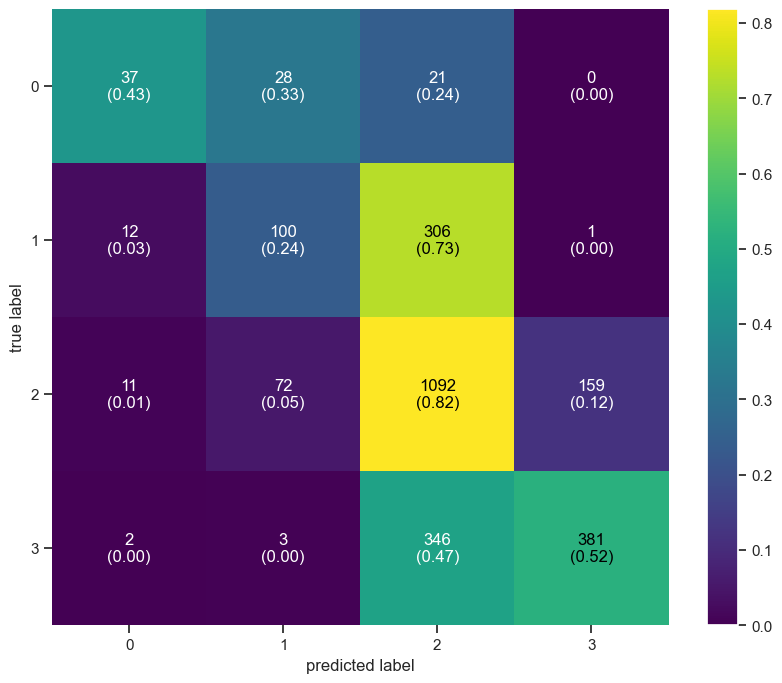

In [15]:
fig, ax = plot_confusion_matrix(conf_mat=confmatrix,
                                colorbar=True,
                                show_absolute=True,
                                show_normed=True,
                                hide_spines=True,
                                cmap='viridis')

for text in ax.texts:
    text.set_color('black' if text.get_color() == 'white' else 'white')

plt.show()

## XG boost

In [16]:
import xgboost as xgb

model = xgb.XGBClassifier(
    )

scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)

model.fit(X_train, y_train)
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

[0.73796791 0.7204667  0.71511911 0.73297665 0.73784047]
0.9648935135660799
0.7471800855698172


In [17]:
# Performance evaluation using the classification_report
y_pred = model.predict(X_test) # predict from the testset


In [18]:
# calculate the confusion matrix
confmatrix = confusion_matrix(y_test,y_pred)

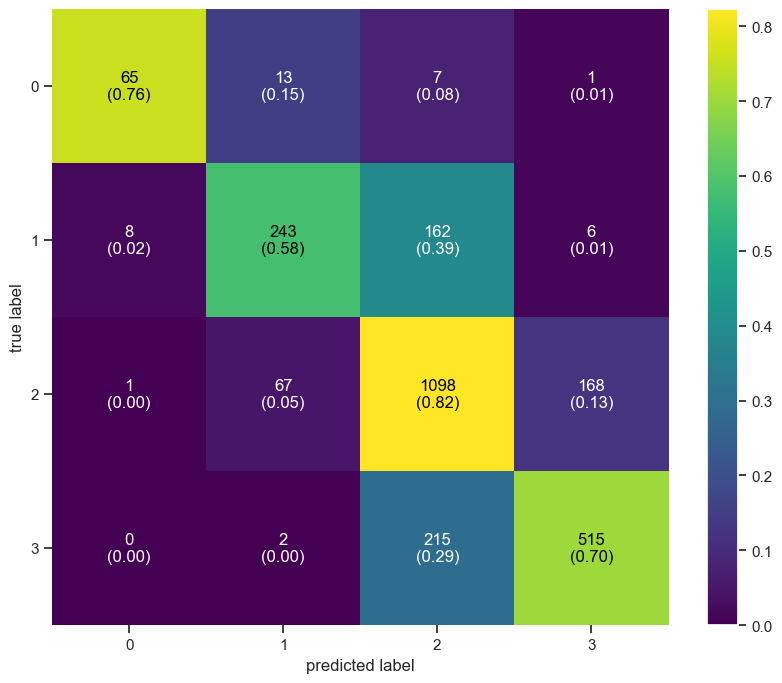

In [19]:
fig, ax = plot_confusion_matrix(conf_mat=confmatrix,
                                colorbar=True,
                                show_absolute=True,
                                show_normed=True,
                                hide_spines=True,
                                cmap='viridis')

for text in ax.texts:
    text.set_color('black' if text.get_color() == 'white' else 'white')

plt.show()

## Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
model = RandomForestClassifier(
    random_state=42,
    max_depth=None,         
    min_samples_leaf=1,    
    min_samples_split=2,   
)

scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)

model.fit(X_train, y_train)
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

[0.74380165 0.73359261 0.7301896  0.74464981 0.74805447]
0.9988330253816979
0.7596266044340724


In [22]:
# Performance evaluation using the classification_report
y_pred = model.predict(X_test) # predict from the testset

In [23]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

confmatrix = confusion_matrix(y_test,y_pred)

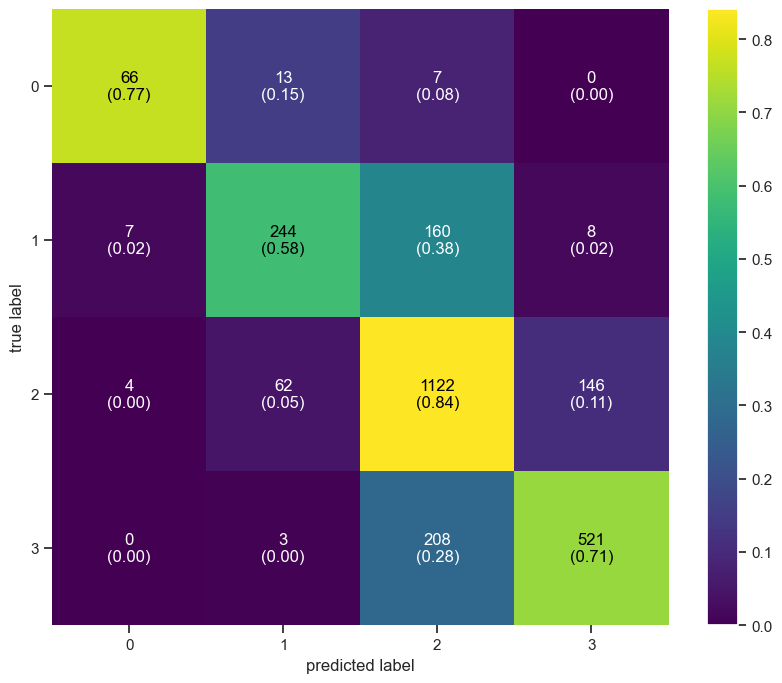

In [24]:
fig, ax = plot_confusion_matrix(conf_mat=confmatrix,
                                colorbar=True,
                                show_absolute=True,
                                show_normed=True,
                                hide_spines=True,
                                cmap='viridis')

for text in ax.texts:
    text.set_color('black' if text.get_color() == 'white' else 'white')

plt.show()

## Visualise results in interactive map

In [25]:
data_test["y_pred"]= y_pred
data_test["y_truth"]= y_test
data_test["y_diff"]= y_pred - y_test

In [26]:
osm_roads = gpd.read_file("data/bcn_osmnx_edges.gpkg")
merged_gdf = osm_roads.merge(data_test, left_on='segment_id', right_on='road_id', how='left')

In [27]:
m = merged_gdf.to_crs(epsg=4326).explore(
    column='y_diff',
    cmap='RdBu',
    tiles='CartoDB positron',
    tooltip=['road_id', 'y_diff', 'y_pred', 'y_truth', 'highway'],
    legend=True,
)
m.save("map_y_diff.html")

import webbrowser, os
webbrowser.open('file://' + os.path.realpath("map_y_diff.html"))

True